# Beyond tiles: colour and background in post

[`beyond_tiles.ipynb`](beyond_tiles.ipynb) solves free-form still-life
portraits. Solving is the expensive half — minutes at 400², thirteen minutes
at 1000², a couple of hours for a poster — and it is also the half that has
nothing to do with how the picture *looks*. The solver only ever decides
which cells are alive.

Everything after that is free. A finished pattern is a plain array of zeros
and ones, so the colours, the backdrop and the print size are all choices you
make afterwards, in milliseconds, as many times as you like. This notebook is
the second half: take one stored still life and turn it into an art piece.

**What you will do here:**

- recover a finished 400² portrait and its subject mask without running a
  solver;
- recolour it in the same **Warhol** style the tile mosaics use, now
  reproducible and guarded against pairs that wash the face out;
- put four kinds of **background** behind it — transparent, flat, an
  elementary cellular automaton, and a still-life agar;
- make the agar backdrop **alive**, so the whole canvas is one verified still
  life you can open in Golly;
- scale the winner up to print size.

No solver runs. The whole notebook is a few seconds.

## 0. Setup

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (REPO / "src", REPO / "experiments"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Every figure below is a grid of full renders; 80 dpi keeps the committed
# notebook a sane size without losing the detail that is being compared.
plt.rcParams["figure.dpi"] = 80

## 1. The expensive part, already done

Two things come out of a solve and both are cheap to recover.

The **pattern** ships in the repository as a bit-packed array — the 400²
portrait from the champion pipeline, 177 seconds of CP-SAT compressed to
about 6 kB on disk.

The **mask** says which cells belong to the subject and which are backdrop.
The solver needs it (background cells are forced dead), and so does anything
that wants to paint behind the subject. It is not stored, because it does not
need to be: it is a deterministic function of the source image, which *is* in
the repository and is already alpha-cut. Recomputing it is one call, pure
PIL, no background-removal model, no solver.

One convention to keep straight, because the two halves of this repository
disagree. The solver's `free_mask` is `True` **on the subject**. The renderer
wants a mask that is `True` **on the background**. So every call below passes
`~free`.

pattern (400, 400), 26,960 live cells (16.9% density)
subject 120,491 cells, background 39,509 cells
live cells sitting in the background: 0


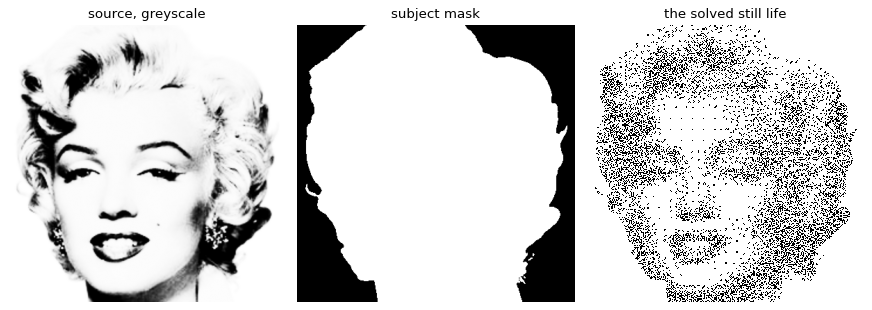

In [2]:
from beyond_tiles.artifacts import ASSETS, load_pattern_asset
from beyond_tiles.targets import grey_and_mask_from_image

SIZE = 400
pattern = load_pattern_asset(ASSETS / "marilyn_400_pipeline.npz")
grey, free = grey_and_mask_from_image(REPO / "input/images/marilyn.png", SIZE)
background = ~free   # the renderer's convention

print(f"pattern {pattern.shape}, {pattern.sum():,} live cells "
      f"({pattern.mean():.1%} density)")
print(f"subject {free.sum():,} cells, background {background.sum():,} cells")
print(f"live cells sitting in the background: {pattern[background].sum()}")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(grey, cmap="gray")
axes[0].set_title("source, greyscale")
axes[1].imshow(free, cmap="gray")
axes[1].set_title("subject mask")
axes[2].imshow(1 - pattern, cmap="gray", interpolation="nearest")
axes[2].set_title("the solved still life")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

That last printed number is the one that matters: **zero** live cells outside
the subject. The mask lines up with the pattern the solver was given, so the
whole background region is empty canvas — free real estate.

## 2. Colour

`ColorScheme` is the same object the tile mosaics use, and `compose` is happy
with any of its presets. Each of these renders in about ten milliseconds.

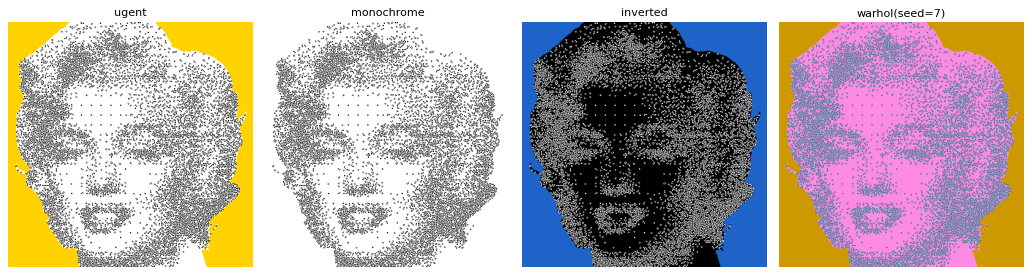

In [3]:
from gol_mosaics import ColorScheme, compose

schemes = [
    ("ugent", ColorScheme.ugent()),
    ("monochrome", ColorScheme.monochrome()),
    ("inverted", ColorScheme.inverted()),
    ("warhol(seed=7)", ColorScheme.warhol(seed=7)),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, (name, scheme) in zip(axes, schemes):
    ax.imshow(np.asarray(compose(pattern, background, scheme, style="flat")))
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.tight_layout()

### The Warhol grid

`ColorScheme.warhol()` draws two colours from a pop-art palette. Two things
changed for this notebook to be usable.

**It takes a seed.** It used to spin up its own random generator, which meant
no seed anywhere in the codebase could reproduce a scheme — every re-run of a
grid like the one below gave different colours, so you could never point at
the one you liked.

**It guards contrast.** A free-form still life carries tone as *local
live-cell density*, not as pixel brightness, so two colours that are close in
brightness do not merely recolour the portrait, they erase it. The palette
contains real offenders — `deep_gold #cc9a00` on `pastel_pink #ff9ecb` are
0.16 apart on a 0-to-1 luma scale. `warhol()` now redraws any pair closer
than `min_luma_gap` (0.35 by default), for the tile mosaics too.

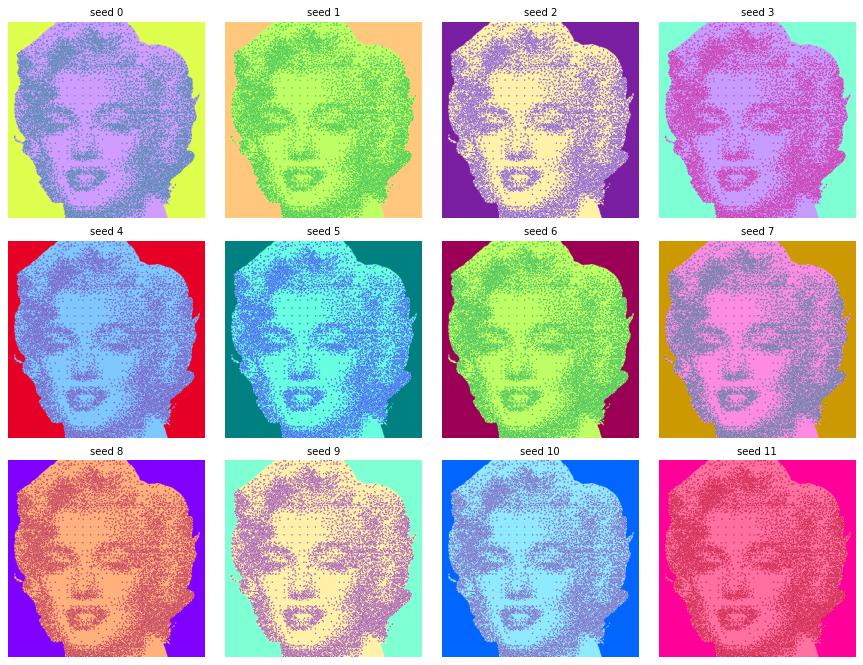

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(11, 8.4))
for seed, ax in enumerate(axes.ravel()):
    ax.imshow(np.asarray(
        compose(pattern, background, ColorScheme.warhol(seed=seed), style="flat")
    ))
    ax.set_title(f"seed {seed}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

Re-run that cell and you get the same twelve panels. Pick a seed and it stays
picked.

## 3. Backgrounds

`compose` offers four backdrop styles, all painted into the mask's background
region and none of them touching the subject:

| style | what it draws | alive? |
|---|---|---|
| `none` | nothing — transparent, for dropping onto another canvas | no |
| `flat` | a solid fill in the scheme's field colour | no |
| `eca` | an elementary cellular automaton, as in the tile mosaics | no |
| `agar` | a lattice of still-life blocks | **yes** |

The first three are paint. They are never part of a Golly export and the
verified still life underneath is untouched. Only `agar` puts down real Game
of Life cells — §4 makes that formal.

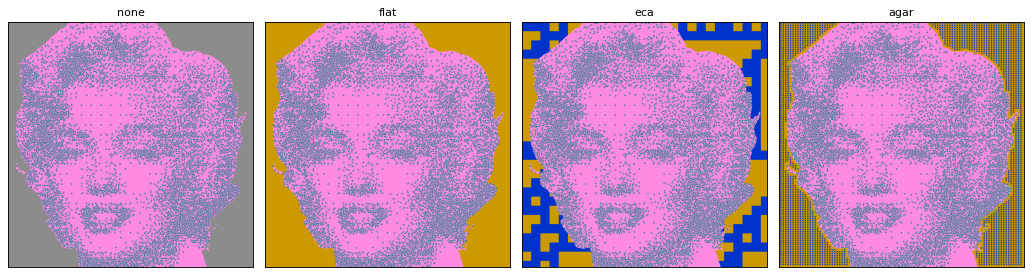

In [5]:
scheme = ColorScheme.warhol(seed=7)
styles = ["none", "flat", "eca", "agar"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, style in zip(axes, styles):
    ax.imshow(np.asarray(
        compose(pattern, background, scheme, style=style, rule=110)
    ))
    ax.set_facecolor("0.55")          # so `none` reads as transparent
    ax.set_title(style, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

### Choosing a texture

The ECA backdrop takes any of Wolfram's 256 rules and a cell size in pixels;
the mosaic pipeline's favourites are collected in `ECABackground.COMPLEX_RULES`
and `CHAOTIC_RULES`. The agar backdrop takes a lattice pitch, which sets how
dense the blocks sit.

complex rules: [54, 147, 110, 124, 137, 193]
chaotic rules: [30, 45, 106, 150]


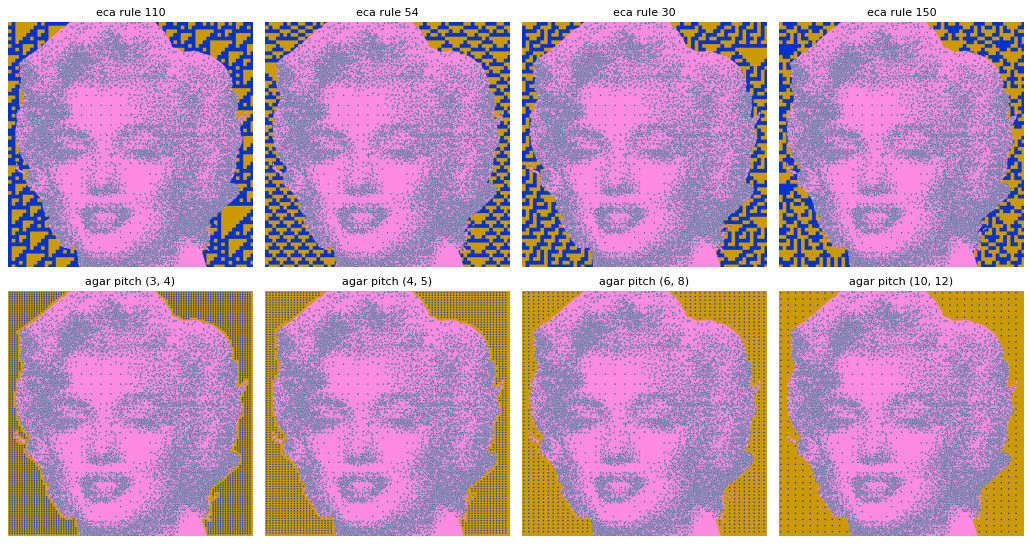

In [6]:
from gol_mosaics import ECABackground

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, rule in zip(axes[0], [110, 54, 30, 150]):
    ax.imshow(np.asarray(compose(pattern, background, scheme,
                                 style="eca", rule=rule, supersample=6)))
    ax.set_title(f"eca rule {rule}", fontsize=10)
for ax, pitch in zip(axes[1], [(3, 4), (4, 5), (6, 8), (10, 12)]):
    ax.imshow(np.asarray(compose(pattern, background, scheme,
                                 style="agar", pitch=pitch)))
    ax.set_title(f"agar pitch {pitch}", fontsize=10)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()

print("complex rules:", ECABackground.COMPLEX_RULES)
print("chaotic rules:", ECABackground.CHAOTIC_RULES)

## 4. A background that is alive

The agar backdrop is not decoration. Merge it into the pattern and the whole
canvas — portrait and backdrop together — is a single Game of Life still
life you can open in Golly and step forever.

Two facts make that work, and neither needed new mathematics.

**The agar is stable for any subset of its blocks.** It is the construction
the beyond-tiles warm-start seeds already use: 2×2 blocks on a lattice with
period 3 in rows and 4 in columns. That asymmetric pitch is the whole trick —
with it, no dead cell can ever see exactly three live neighbours no matter
which sites are filled, so dropping blocks wherever the mask says "subject"
is safe by construction. No repair pass, no seams. (A square period-3 lattice
does *not* have this property, which is why the pitch is 3×4.)

**The two populations never meet.** A block is kept only where the mask is
background for two cells in every direction. That puts every agar cell at
Chebyshev distance 3 or more from every subject cell, so no dead cell's 3×3
neighbourhood can contain one of each. Neither population sees the other,
both keep the neighbour counts they were verified with, and the union is
stable.

`life_safe_pattern` does the merge and refuses if the pattern has live cells
in the background region, where the guarantee would not hold.

subject 26,960 + agar 6,588 = 33,548 live cells
verify: {'bounded': True, 'toroidal': True}
exported output/golly/beyond_tiles_art.cells (157 kB)


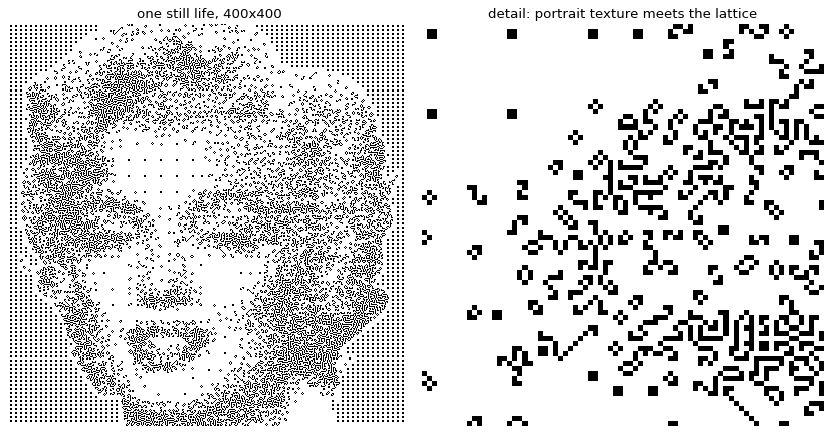

In [7]:
from gol_mosaics import life_safe_pattern
from gol_mosaics.export import GollyExporter
from beyond_tiles.still_image import verify_still_life

whole = life_safe_pattern(pattern, background, pitch=(4, 5))
print(f"subject {pattern.sum():,} + agar {whole.sum() - pattern.sum():,} "
      f"= {whole.sum():,} live cells")
print("verify:", verify_still_life(whole))

out = REPO / "output/golly/beyond_tiles_art.cells"
GollyExporter.export_to_cells(whole, str(out))
print("exported", out.relative_to(REPO), f"({out.stat().st_size / 1024:.0f} kB)")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.4))
axes[0].imshow(1 - whole, cmap="gray", interpolation="nearest")
axes[0].set_title("one still life, 400x400")
axes[1].imshow(1 - whole[150:230, 150:230], cmap="gray", interpolation="nearest")
axes[1].set_title("detail: portrait texture meets the lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

`{'bounded': True, 'toroidal': True}` — stable both as a finite pattern and
wrapped on a torus. The detail panel is the interesting part: on the left the
solver's texture, in which 92% of 6×6 blocks occur exactly once, and on the
right a perfectly regular lattice. Same rule set, same picture, and the seam
between them is nothing but empty space.

## 5. Make the print

The renderer emits one pixel per cell, which is not a print. `scale` is an
integer nearest-neighbour upscale — nearest-neighbour on purpose, because
every cell should stay a hard-edged square rather than being smoothed into a
grey blur.

In [8]:
for scale in (1, 3, 6, 12):
    px = SIZE * scale
    print(f"scale {scale:2d}  ->  {px:5d} x {px:5d} px "
          f"= {px / 300 * 2.54:5.1f} cm at 300 dpi")

scale  1  ->    400 x   400 px =   3.4 cm at 300 dpi
scale  3  ->   1200 x  1200 px =  10.2 cm at 300 dpi
scale  6  ->   2400 x  2400 px =  20.3 cm at 300 dpi
scale 12  ->   4800 x  4800 px =  40.6 cm at 300 dpi


1200 x 1200 px, 49 kB -> output/images/beyond_tiles_art.png


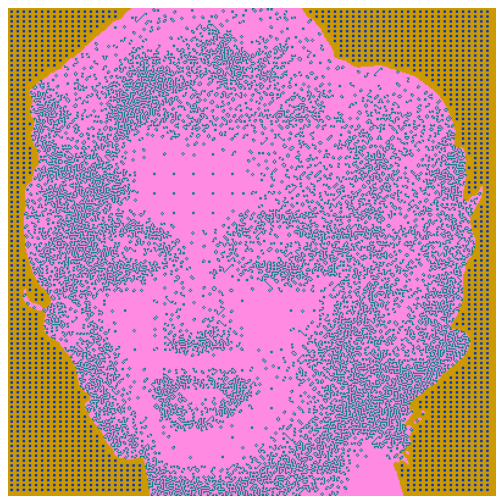

In [9]:
art = compose(pattern, background, ColorScheme.warhol(seed=7),
              style="agar", pitch=(4, 5), scale=3)
png = REPO / "output/images/beyond_tiles_art.png"
art.save(png)
print(f"{art.size[0]} x {art.size[1]} px, {png.stat().st_size / 1024:.0f} kB "
      f"-> {png.relative_to(REPO)}")

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.imshow(np.asarray(art))
ax.axis("off")
plt.tight_layout()

At 400² a print stays small — 3.4 cm at scale 1, 34 cm only at scale 12,
where each cell is a visible 12-pixel square. That is a legitimate look, but
it is also why the flagship runs go bigger: the 1000² pipeline run and the
1416×2000 poster carry the same physical size at a fraction of the scale, so
the cells disappear into texture instead of becoming the texture.

## 6. The poster

The John Conway run is 1416×2000 cells — a real poster, solved once in
[`poster.py`](../experiments/beyond_tiles/poster.py) and then dressed however
you like. Its output lives under `experiments/beyond_tiles/results/`, which is
gitignored, so this cell runs only if you have solved it locally:

```bash
python experiments/beyond_tiles/poster.py input/images/john.png \
    --width 1416 --height 2000 --out results/john_d40
```

The mask comes back from `poster.load_rect`, with the same geometry the solve
used — no square padding, straight to the poster's aspect ratio.

(2000, 1416), 400,660 live cells, 0 in the background


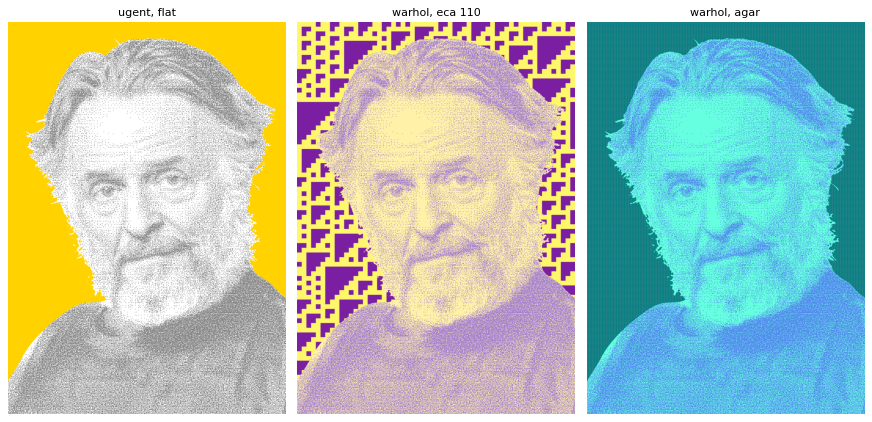

In [10]:
run = REPO / "experiments/beyond_tiles/results/john_d40"

if (run / "pattern.npy").exists():
    import json
    from beyond_tiles.poster import load_rect

    report = json.loads((run / "report.json").read_text())
    height, width = report["grid"]
    john = np.load(run / "pattern.npy")
    # Tone and contrast shape the grey targets, never the alpha mask, so the
    # geometry alone is enough to recover it.
    _, john_free = load_rect(str(REPO / report["image"]), width, height,
                             tone="raw", contrast=5.0)
    john_bg = ~john_free
    print(f"{john.shape}, {john.sum():,} live cells, "
          f"{john[john_bg].sum()} in the background")

    fig, axes = plt.subplots(1, 3, figsize=(11, 5.6))
    for ax, (title, kwargs) in zip(axes, [
        ("ugent, flat", dict(scheme=ColorScheme.ugent(), style="flat")),
        ("warhol, eca 110", dict(scheme=ColorScheme.warhol(seed=2),
                                 style="eca", rule=110, supersample=24)),
        ("warhol, agar", dict(scheme=ColorScheme.warhol(seed=5),
                              style="agar", pitch=(6, 8))),
    ]):
        ax.imshow(np.asarray(compose(john, john_bg, **kwargs)))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
else:
    print(f"no local run at {run.relative_to(REPO)} - see the command above")

## 7. Where to go next

- [`beyond_tiles.ipynb`](beyond_tiles.ipynb) is the other half: how these
  patterns get solved, why 400² is a wall, and the three escapes that get
  past it.
- `compose`, `agar_background` and `life_safe_pattern` are ordinary package
  functions (`gol_mosaics.compose`) and work on tile mosaics just as well —
  a mosaic's `transparency_mask` is already in the renderer's convention, so
  it needs no `~`.
- The obvious next backdrop is a **tile mosaic** behind a free-form subject:
  two still lifes from opposite ends of this repository in one image. The
  lattice machinery is in `gol_mosaics.tile_scheme`; interlocking it with a
  free-form pattern needs its own stability argument, which the block agar
  above gets for free and a diamond lattice does not.